### Set Up
Importing all the different libraires needed, setting up the paths to each of the files, and the specific coordinates (RA, Dec) of the main object (these are found in the .FITS file title)

In [1]:
# -- Import Libraries --
import astropy
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.table import Table
import astropy.units as u
from astropy.visualization import ZScaleInterval, ImageNormalize
from astropy.wcs import WCS

import photutils
from photutils.aperture import SkyCircularAperture, aperture_photometry

import numpy as np

from scipy.ndimage import shift, zoom

import matplotlib.pyplot as plt
#this ensures that the graphs are not PNGs
%matplotlib widget 
from matplotlib.colors import LogNorm

# -- Path to the different Files --
main_image_cutout = r"FITS\cutout_192.6009_-28.2675.fits"
main_image_psf = r"FITS\copsf_192.6009_-28.2675.fits"
neighbors_image = r"FITS\cat-ls-dr10.fits"

#define the object coordinates we are interested in
main_object_ra = 192.6010
main_object_dec = -28.2669

### Opening and Viewing the FITS Files

#### The Main Cutout
First, we open the main image cutout file and inspect it using the `.info()` function. After that, we go deeper and navigate the header of this file, as well as the data category. From there, we find the r-band, which contains our image under the r-band.

In [2]:
with fits.open(main_image_cutout) as hdu_list: #use with to safely close the file
    hdu_list.info() 
    header = hdu_list[0].header
    print(f"header (hdu_list[0].header): {header}")
    image_data = hdu_list[0].data #shape: (4, 256, 256)
    print(f"image data (hdu_list[0].data): {image_data}")
    r_band = image_data[1] #red is index 1 #this is fluxes
    print(f"r band (image_data[1]): {r_band}")

Filename: FITS\cutout_192.6009_-28.2675.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      29   (256, 256, 4)   float32   
header (hdu_list[0].header): SIMPLE  =                    T / file does conform to FITS standard             BITPIX  =                  -32 / number of bits per data pixel                  NAXIS   =                    3 / number of data axes                            NAXIS1  =                  256 / length of data axis 1                          NAXIS2  =                  256 / length of data axis 2                          NAXIS3  =                    4 / length of data axis 3                          EXTEND  =                    T / FITS dataset may contain extensions            COMMENT   FITS (Flexible Image Transport System) format is defined in 'AstronomyCOMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H SURVEY  = 'LegacySurvey'                                                   

**Plotting** <br>
To plot, we use the ZScaleInterval Image Normalizer, and the gray colormap. The Matplotlib library makes the process extremely easy.

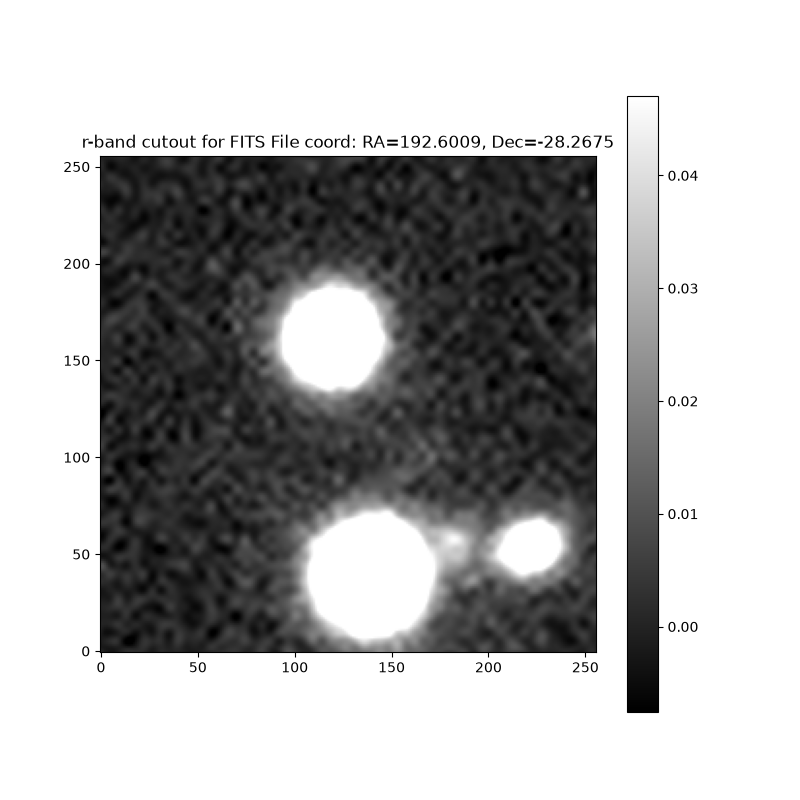

In [3]:
norm = ImageNormalize(r_band, interval=ZScaleInterval())
plt.figure(figsize=(8,8))
plt.imshow(r_band, origin="lower", norm=norm, cmap='gray')
plt.colorbar()
plt.title('r-band cutout for FITS File coord: RA=192.6009, Dec=-28.2675')
plt.show()

#### The PSF Image
After inspecting the r-band image and its structure, we can look at the downloaded PSF Image, which shows the "shape" of the main object, at coordinates: RA 192.6009, Dec -28.2675.
<br>Again, we open the file and extract the basic information, then dive deeper by looking at the `.data` in index 0.
<br>Initially, the image was not bright enough, so we mulitplied this by a factor of 1.31, which was found by dividing the brightest point on the original image by the brightest point on the PSF image. However, in the future we also had to zoom the PSFs as the resolution was different. 
<br>The shape (`psf_data.shape`) is the dimentions of the array stored inside the FITS File.<br>
    -> NAXIS1 is 1D Arrays, NAXIS2 is 2D Arrays, NAXIS3 is 3D Arrays.<br>
For plotting, we do the same thing but change the data to the psf's data, and use a different colormap.

Filename: FITS\copsf_192.6009_-28.2675.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      14   (63, 63)   float32   
  1                1 ImageHDU         8   (63, 63)   float32   
  2                1 ImageHDU         8   (63, 63)   float32   
  3                1 ImageHDU         8   (63, 63)   float32   
PSF shape: (63, 63)
PSF sum: 1.31


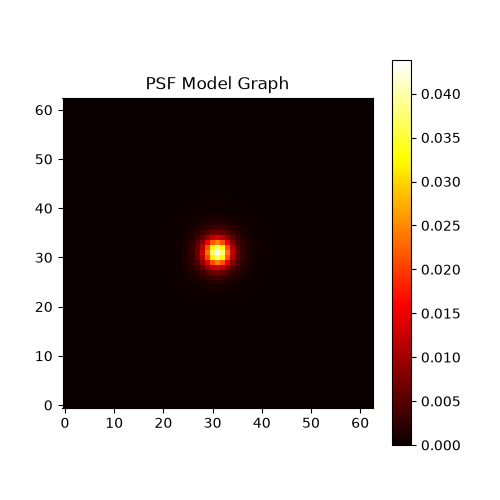

In [4]:
with fits.open(main_image_psf) as psf_hdu_list:
    psf_hdu_list.info()
    psf_data = psf_hdu_list[0].data * 1.31 #found this multiplication factor by dividing brightest point on og image by the brightest point on psf image

    print('PSF shape:', psf_data.shape) #the dimentions of the array -> NAXIS1 is 1D Arrays, NAXIS2 is 2D Arrays, NAXIS3 is 3D Arrays
    print('PSF sum:', psf_data.sum()) # A PSF that sums to 1.0 means: "if I stamp this at a location and scale it by flux F, the total flux contributed to the image equals F."

plt.figure(figsize=(5,5))
plt.imshow(psf_data, origin='lower', cmap='hot')
plt.colorbar()
plt.title('PSF Model Graph')
plt.show()

#### The Neighbors Image
As we don't have to actually see the image, to open the Neighbors Image, we can use Astropy's `Table` module, by running `Table.read()`. This automatically handles things such as closing the file (no need for a `with` block)<br>
Using Numpy and the Astropy Table, we can look filter and read the different types (such as PSF, EXP, REX, etc.). <br>
From here, we could either sort for PSF sources only, or treat the other identified neighbors sources as PSFs.

In [5]:
# -- Opening and Inspecting the Neighbors Image --
neighbors = Table.read(neighbors_image) #Table.read already handles the closing of the file so no with block needed

print(np.unique(neighbors['type'])) #check the different exitsting types (e.g., PSF, EXP, REX, etc.)

psf_neighbors_sources = neighbors 
#psf_neighbors_sources = neighbors[neighbors['type'] == b'PSF'] #Filter for PSF types ONLY
print(f"Total Neighbors: {len(neighbors)}")
print(f"Total PSF Sources: {len(psf_neighbors_sources)}")

[b'DEV' b'EXP' b'PSF' b'REX' b'SER']
Total Neighbors: 66
Total PSF Sources: 66


### World Coordinate System Conversion
The World Coordinate System is what allows for the conversion of pixel coordinates (x, y) to **sky coordinates** (RA, Dec), and vice versa. <br>
In FITS files, a set of keywords is stored <u>in the header</u> describing this transformation.<br>
This conversion can be extremely confusing (because the sky is curved), but the `astropy.wcs` module allows to inser a sky position and outputs which pixels on the image that corresponds to, or vice versa.

In our case, this conversion is needed because the neighbors catalog is in RA and Dec in degrees, but the image for the r_band is a 2D numpy array. <br>
First, we connect to the main image cutout's header. The `.celestial` property automatically removes non-spacial dimentions, dropping the WCS down to a 2D system. <br>
After that, we set the variables `img_ny` and `img_nx` to the size (shape) of our image <br>
<br>
Next, to ensure that everything is aligned correctly, we convert each of the corner pixls to the world coordinate system, achieving a full ky coordinates perimeter covering (from the minimum to maximum Right Ascension and Declination)


In [6]:
wcs = WCS(header).celestial #connect to main image cutout header to access those keywords
#the .celestial property automatically removes non-spacial dimentions, dropping the WCS down to a 2D system 

img_ny, img_nx = r_band.shape #Set the variables to the size of our image 

#setting corner pixels to wolrd coordinate system
bottom_left = wcs.pixel_to_world(0,0)
bottom_right = wcs.pixel_to_world(img_nx, 0)
top_left = wcs.pixel_to_world(0, img_ny)
top_right = wcs.pixel_to_world(img_nx, img_ny)

ra_min  = min(bottom_left.ra.deg,  bottom_right.ra.deg,  top_left.ra.deg,  top_right.ra.deg)
ra_max  = max(bottom_left.ra.deg,  bottom_right.ra.deg,  top_left.ra.deg,  top_right.ra.deg)
dec_min = min(bottom_left.dec.deg, bottom_right.dec.deg, top_left.dec.deg, top_right.dec.deg)
dec_max = max(bottom_left.dec.deg, bottom_right.dec.deg, top_left.dec.deg, top_right.dec.deg)
#this outputs sky coordinates: RA, Dec (Right Accrension, Declination)

print(f"RA covering: {ra_min:.4f} -> {ra_max:.4f} degrees") 
print(f"DEC covering: {dec_min:.4f} -> {dec_max:.4f} degrees") 

RA covering: 192.5985 -> 192.6033 degrees
DEC covering: -28.2696 -> -28.2654 degrees


#### Filtering the Neighbor Sources
Once that the area is mapped correctly, we need to filter all the neighboring sources so that we select only those in our specified area. <br>
After the code is executed, xs and ys are arrays that contain all the coordinates of found objects in the specified area.

In [7]:
# Filtering the neighbor catalog to only sources in the specified RA and Dec coverage
filtered_neighbors_list = (
    (psf_neighbors_sources['ra'] >= ra_min) & (psf_neighbors_sources['ra'] <= ra_max) & (psf_neighbors_sources['dec'] >= dec_min) & (psf_neighbors_sources['dec'] <= dec_max)    
)
filtered_psf_neighbors = psf_neighbors_sources[filtered_neighbors_list]
print(f"PSF sources in this image's field: {len(filtered_psf_neighbors)}")

xs, ys = wcs.world_to_pixel_values(filtered_psf_neighbors['ra'], filtered_psf_neighbors['dec'])
#xs and ys are numpy arrays, one pixel coordinate per source
print(f"xs= {xs}")
print(f"ys = {ys}") #testing to check whether the arrays actually have something stored inside
#these two values are the x and y coordinates for each of the filtered psf neighbors


PSF sources in this image's field: 6
xs= [221.76030065 182.81635609 164.85047958 139.816458   119.85736137
  74.7647968 ]
ys = [ 53.73152207  56.84741772 103.0135797   38.95061043 161.57922979
 183.13563722]


**Verification of WCS and PSF Sources Identification**<br>
To ensure that everything works, we will plot green circles over each of the found objects by using the `xs` and `ys` arrays.

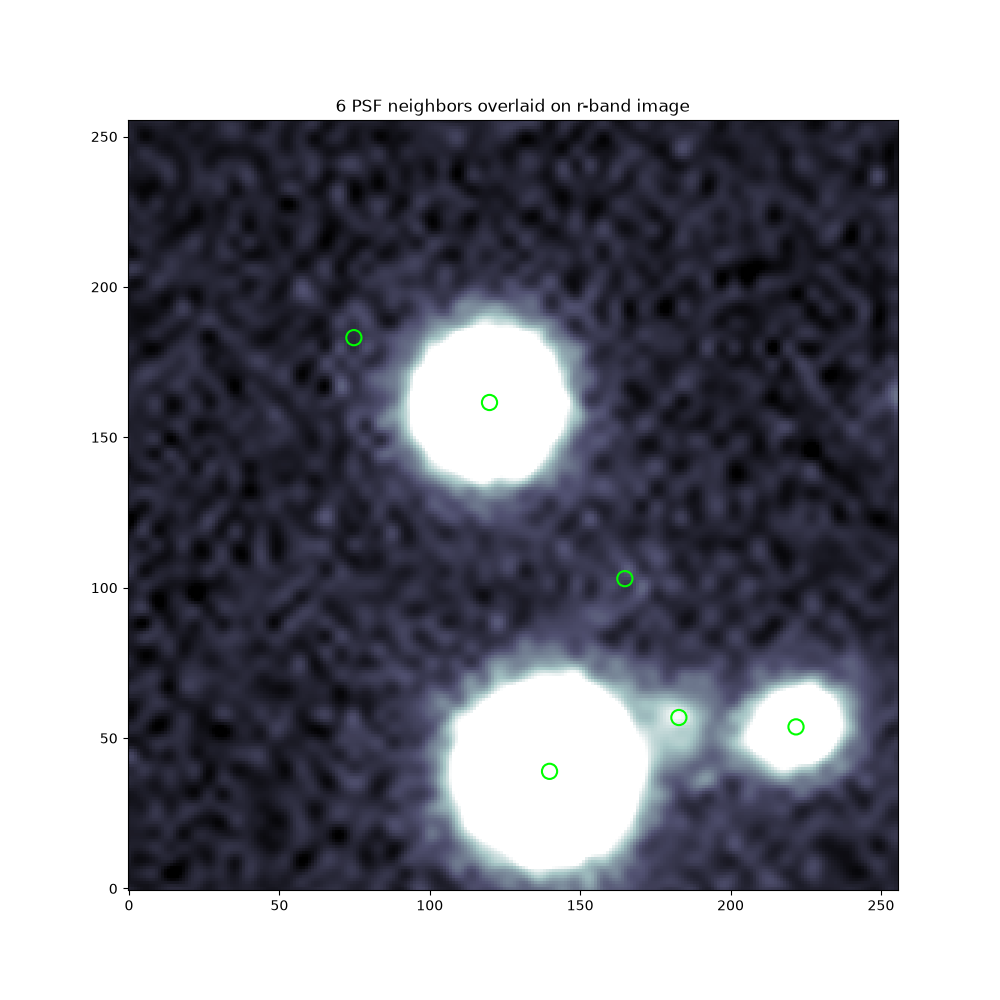

In [8]:
# WCS Verification by OVERPLOTTING the different PSF sources on the r-band image
norm = ImageNormalize(r_band, interval=ZScaleInterval())
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(r_band, origin='lower', norm=norm, cmap='bone')
ax.scatter(xs, ys, s=120, facecolors='none', edgecolors='lime', linewidths=1.5)
ax.set_title(f'{len(filtered_psf_neighbors)} PSF neighbors overlaid on r-band image')
plt.show()

### PSF Synthetic Image Creation and Placement

In [9]:
fluxes = filtered_psf_neighbors['flux_r']
print(fluxes)

  flux_r  
----------
 5.3749347
0.69680977
0.37526524
 113.39523
 47.730133
0.11704256


#### Excluding the Main Object from the Synthetic Image
As seen from the previous WCS Verification Plot (Figure 3), the main object is being identified as a neighboring source. If this isn't manually removed from the neighbors table, when creating the synthetic image, the main object will be subtracted too.<br>
<br>
To ensure this doesn't happen, we firstly calculate the distance on the sky between the main object and every single other object in the nieghbor list (all at the same time), using $a^2$ + $b^2$ = $c^2$<br>
After that, we find the object closest to the target's coordinats by using `np.argmin()`, which finds the smallest number in the `main_object_distances` array (therefore the shortest distance from the main object).<br>
Next, we filter through the array, identifying which item not to keep, using `!= main_obj_index`. This outputs a True/False list.<br>
Once the filter is created, we apply it to the data arrays (X coordinates, Y coordinates, and Flux Values), to create new lists that are completely target-free.<br>
The result is new xs, ys, and flux lists that only contain the information of the nearby neighbor sources.<br>

In [10]:
#find and exclude the main object 
main_object_distances = np.sqrt((filtered_psf_neighbors['ra'] - main_object_ra)**2 + (filtered_psf_neighbors['dec'] - main_object_dec)**2) #the distance from every source to the object we're interested in
main_obj_index = np.argmin(main_object_distances) #find the index of the main object by finding the smallest distance

psf_object_KEEP = np.arange(len(filtered_psf_neighbors)) != main_obj_index

xs_without_target = xs[psf_object_KEEP]
ys_without_target = ys[psf_object_KEEP]
fluxes_without_target = filtered_psf_neighbors['flux_r'][psf_object_KEEP]

#### PSF Image Creation and Placement **Function**
This function is what allows for the creation of a Synthetic PSF Image that we can then subtract from the original image to obtain a disturbances-free, "clean" image.<br>
<br>
The first step is to create a blank background canva, using `np.zeros()`. This creates a grid of pixels where every pixel start with a value of 0 (black).<br>
`psf_h` and `psf_w` sets the height and width of the PSF "stamps" in pixels, while `psf_cy` and `psf_cx` find the exact middle pixel of the stamp (h and w / 2).<br>
<br>
The `for` loop, runs through each one of the objects and prepares their coordinates. The `zip()` function takes three separate lists (all the x and y positions, and the fluxes), and matches them with individual object profiles, each with their own X and Y coordinates, and Brightness Values.<br>
After that, we calculate the boundaries of where the stamps will sit on the canvas. For example, if an object is supposed to be at pixel 135, and the stamp is 25 pixels wide (meaning that the center is at 12), the left edge of the stamp will have to start at pixel 123 -> 135 - 12 <br>
The Edges are then handled by using `max(x0, 0)`, whcih forces a stamp's edge to start at 0 if its left edge is a negative number, and `min(x1, img_w)`, whcih chops off the stamp at the maximum width if an edge goes past the width of the canvas.<br>
If an object is completely outside the image, it is skipped.

In [11]:
def create_synthetic_image(image_shape, psf, sources_x, sources_y, fluxes): #takes the real size of the image, the psf stamp, the xs and xy arrays from the WCS conversion, and the fluxes (how bright each object is)
    synthetic = np.zeros(image_shape, dtype=np.float64) # creating a BLANK CANVAS, a 256 x 256 grid
    psf_h, psf_w = psf.shape
    psf_cy, psf_cx = psf_h // 2, psf_w // 2 #identifying the center pixel of the PSF Image (height and width / 2)

    img_h, img_w = image_shape

    for x, y, flux in zip(sources_x, sources_y, fluxes): #zip allows to combine the 3 lists in triplets (x1, y1. flux1), (x2, y2, flux2), etc. #this means that we are going through each one of the identified objects

        ix, iy = int(round(x)), int(round(y)) #round the pixel position to the nearest pixel
        print(ix, iy, flux)

        # calculate where the PSF stamp lands in the image, centering it on the object position
        #Say the object is at pixel x=135, and the sticker is 25 pixels wide with center at index 12. If you want the sticker's center pixel to land exactly on x=135, the sticker's left edge (x0) must start at 135 - 12 = 123. Then the sticker's right edge (x1) is 123 + 25 = 148. So the sticker occupies columns 123 through 148 in the big image, and its middle column (135) lines up exactly with the object.
        x0 = ix - psf_cx
        y0 = iy - psf_cy
        x1 = x0 + psf_w
        y1 = y0 + psf_h
        
        # Clip to image boundaries
        img_x0 = max(x0, 0);  img_x1 = min(x1, img_w) #if the column < 0, set it = 0
        img_y0 = max(y0, 0);  img_y1 = min(y1, img_h) #the right edge of the psf cannot go past the image's width
        psf_x0 = img_x0 - x0; psf_x1 = psf_x0 + (img_x1 - img_x0)
        psf_y0 = img_y0 - y0; psf_y1 = psf_y0 + (img_y1 - img_y0)
        
        if img_x1 <= img_x0 or img_y1 <= img_y0:
            continue  # source is fully outside image, skip
        
        synthetic[img_y0:img_y1, img_x0:img_x1] += flux * psf[psf_y0:psf_y1, psf_x0:psf_x1] #equation to create the psf
    
    return synthetic

synthetic_image = create_synthetic_image(r_band.shape, psf_data, xs_without_target, ys_without_target, fluxes_without_target) #create image WITHOUT the main object
synthetic_image_data = synthetic_image.data
#assign the arguments: image shape (the r-band shape), the psf data, the xs and ys coordinates for each psf, and the fluxes for each psf

222 54 5.3749347
183 57 0.69680977
165 103 0.37526524
140 39 113.39523
75 183 0.11704256


#### **Plotting** the Synthetic Image
Logarithmic Scale is Used with 0.1 as the minimum and `r_band.max()` as the maximum brighness

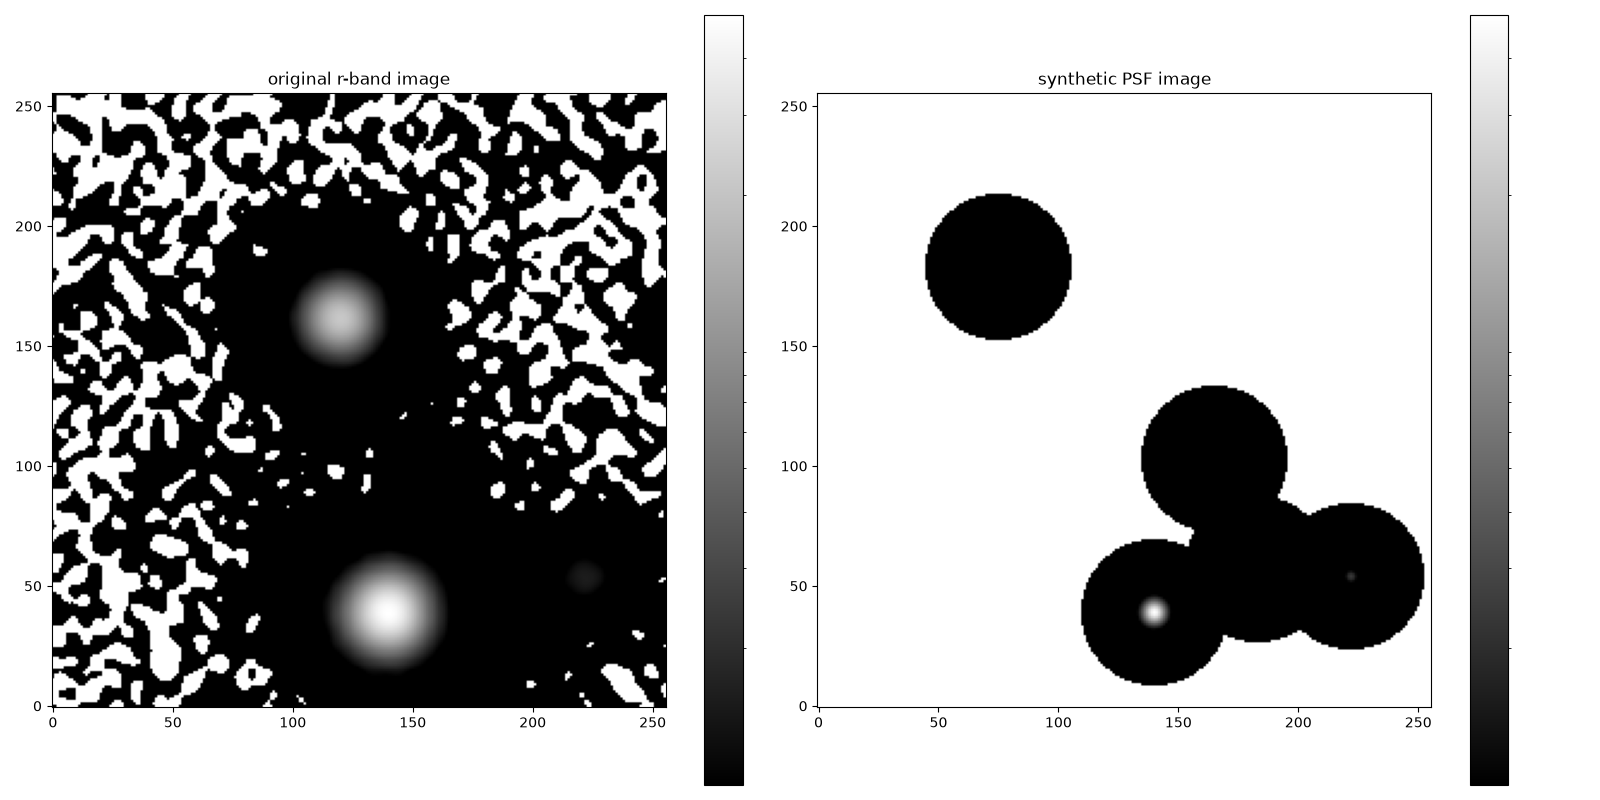

In [12]:
# plotting in LOGARTITHMIC scale
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
LogNorm_minimum_value = 0.1 #minumum value to handle fully black
LogNorm_maximum_value = r_band.max() #minumum value to handle fully black

logarithmic_image1 = axes[0].imshow(r_band, origin="lower", norm=LogNorm(vmin=LogNorm_minimum_value, vmax=LogNorm_maximum_value), cmap="gray")
axes[0].set_title('original r-band image')
logarithmic_image2 = axes[1].imshow(synthetic_image, origin="lower", norm=LogNorm(vmin=LogNorm_minimum_value, vmax=LogNorm_maximum_value), cmap="gray")
axes[1].set_title('synthetic PSF image')


low_tick = np.percentile(r_band[r_band > 0], 20) #ticks for image 1
medium_tick = np.percentile(r_band[r_band > 0], 50)#calculate percentiles using only positive pixels to avoid math issues
high_tick = np.percentile(r_band[r_band > 0], 90)
low_tick2 = np.percentile(synthetic_image[synthetic_image > 0], 20) #ticks for image 2
medium_tick2 = np.percentile(synthetic_image[synthetic_image > 0], 50)
high_tick2 = np.percentile(synthetic_image[synthetic_image > 0], 90)


cbar_1 = fig.colorbar(logarithmic_image1, ax=axes[0], ticks=[low_tick, medium_tick, high_tick]) # Create specific colorbars for each of the images
cbar_2 = fig.colorbar(logarithmic_image2, ax=axes[1], ticks=[low_tick, medium_tick, high_tick]) 
# Format the labels
cbar_1.ax.set_yticklabels([f"{int(low_tick):,}", f"{int(medium_tick):,}", f"{int(high_tick):,}"])
cbar_2.ax.set_yticklabels([f"{int(low_tick):,}", f"{int(medium_tick):,}", f"{int(high_tick):,}"])

plt.tight_layout()

#### Image Resizing for Higher Accuracy
As seen from Figure 4, the brightness of each found object in the synthetic psf image still doesn't match the original brightness in the main image. Therefore, to find the the quantity of the affecting factor, we create a simple line graph displaying the difference in brightness of each objects (a single object to inspect was selected).

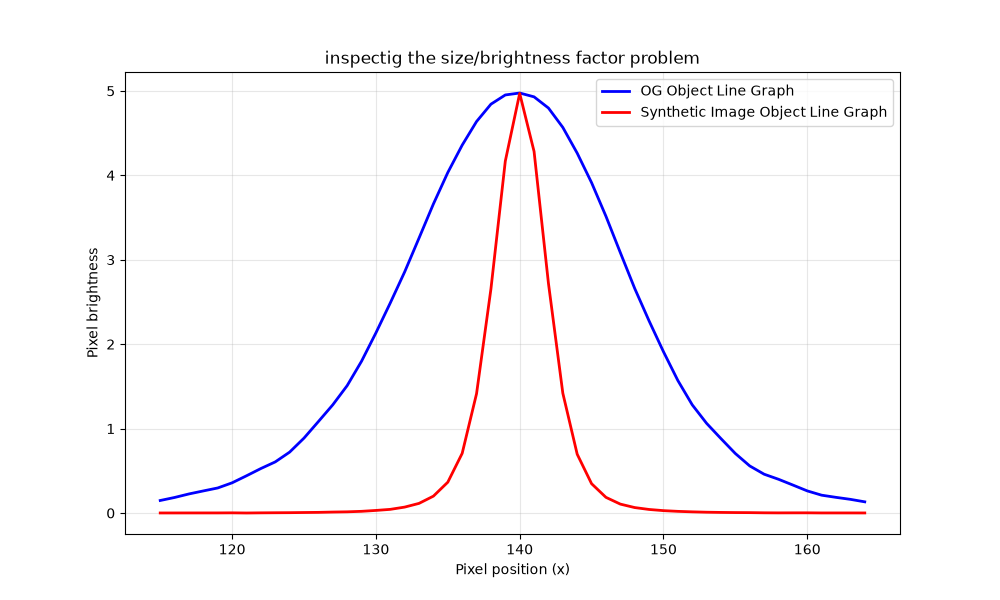

(63, 63)


In [13]:
# -- IDENTIFICATION OF THE SIZE/BRIGHTNESS FACTOR PROBLEM --
#identify the lowest y-value in the array to find the bottom object (what we will use as reference to find the mismatch)
bottom_object_coord = np.argmin(ys) #get the lowest value in the array

btm_obj_x = int(round(xs[bottom_object_coord])) #round coords to nearest 
btm_obj_y = int(round(ys[bottom_object_coord]))

#slicing the object in the center
slice_center_row = btm_obj_y
slice_start_col = btm_obj_x - 25 #creating a 50x50 around the object (the area that we will graph)
slice_end_col = btm_obj_x + 25

og_line_graph = r_band[slice_center_row, slice_start_col:slice_end_col] #the logic is r_band[50,100] outputs the brightness (the flux value) at row 50, column 100
synthetic_line_graph = synthetic_image[slice_center_row, slice_start_col:slice_end_col]
line_graph_px_positions = np.arange(slice_start_col, slice_end_col)

plt.figure(figsize=(10, 6))
plt.plot(line_graph_px_positions, og_line_graph, label='OG Object Line Graph', color='blue', linewidth=2)
plt.plot(line_graph_px_positions, synthetic_line_graph, label='Synthetic Image Object Line Graph', color='red', linewidth=2)
plt.xlabel('Pixel position (x)')
plt.ylabel('Pixel brightness')
plt.title('inspectig the size/brightness factor problem')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(psf_data.shape)

As we can see, there is a large difference between the brightness in the original and synthetic image, therefore, we will use Scipy's `zoom()` function to resize the PSF image.
To find how much we must zoom the image by, we measure the width of each curve at the middle, and find the difference. In our case, it was a factor of 4.

SUM: 21.52777671813965
222 54 5.3749347
183 57 0.69680977
165 103 0.37526524
140 39 113.39523
75 183 0.11704256


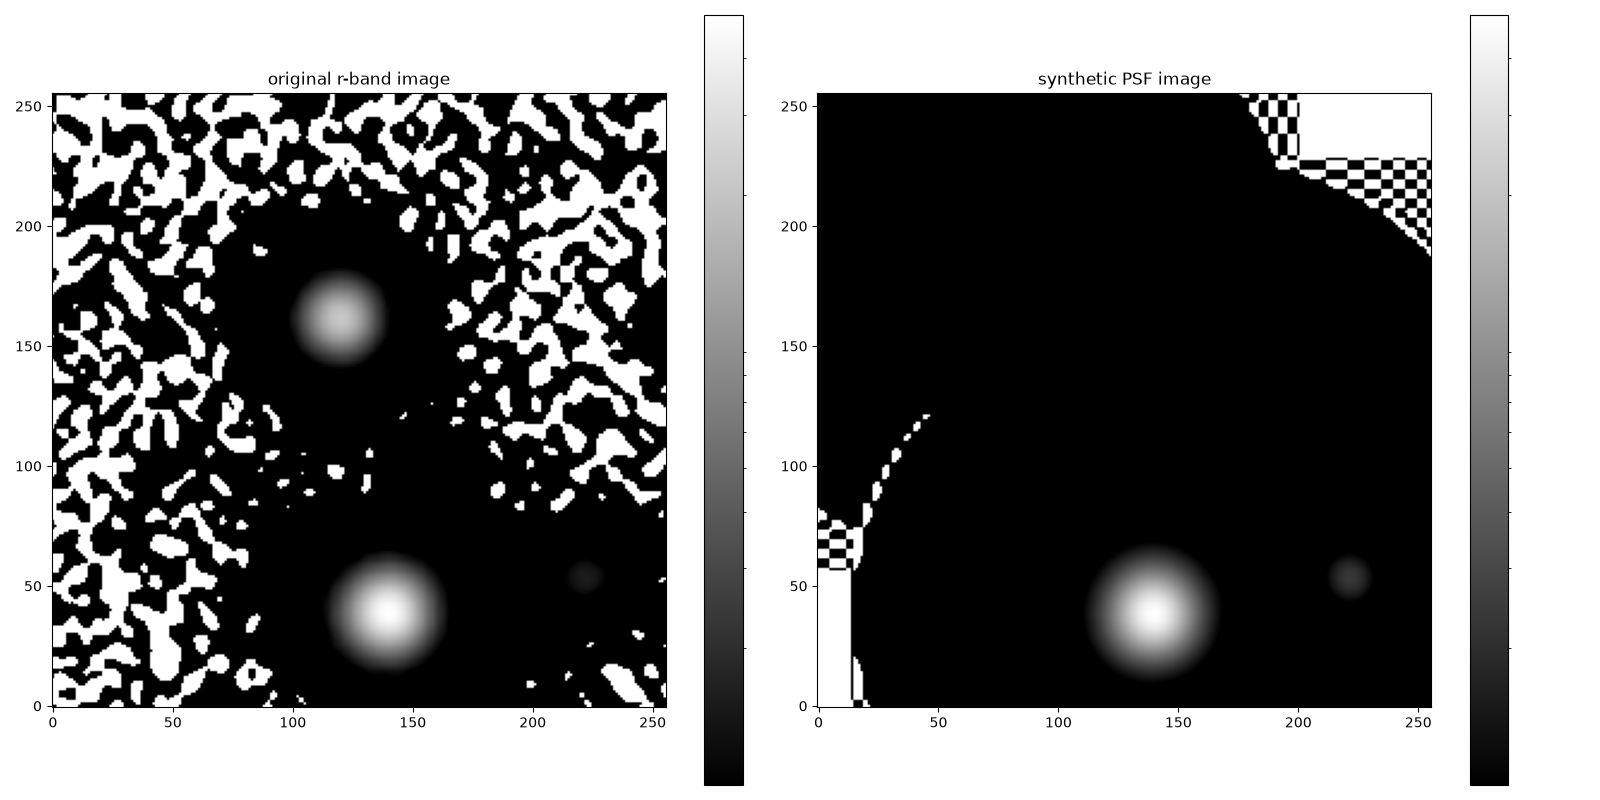

 shape_r  
----------
       0.0
0.39228863
0.68895924
 0.3721094
       0.0
 1.1097971
       0.0
 0.5227618
0.26090693
 0.5468132
       ...
0.41285828
 0.8886939
       0.0
       0.0
       0.0
       0.0
0.79107535
 0.6282477
0.32662442
 1.7746859
Length = 66 rows
222 54 5.3749347
183 57 0.69680977
165 103 0.37526524
140 39 113.39523
75 183 0.11704256


In [14]:
psf_data_enlarged = zoom(psf_data, 4, order=3) #the image to enlarge, the scale factor, the order (cubic interpolation allows for a smooth result)
psf_data_enlarged = psf_data_enlarged / psf_data_enlarged.max() * psf_data.max() #renormalize everything to ensure that sum = 1

print(f"SUM: {psf_data_enlarged.sum()}") #verify sum = 1

#replot
synthetic_image = create_synthetic_image(r_band.shape, psf_data_enlarged, xs_without_target, ys_without_target, fluxes_without_target)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
LogNorm_minimum_value = 0.1 #minumum value to handle fully black
LogNorm_maximum_value = r_band.max() #minumum value to handle fully black

logarithmic_image1 = axes[0].imshow(r_band, origin="lower", norm=LogNorm(vmin=LogNorm_minimum_value, vmax=LogNorm_maximum_value), cmap="gray")
axes[0].set_title('original r-band image')
logarithmic_image2 = axes[1].imshow(synthetic_image, origin="lower", norm=LogNorm(vmin=LogNorm_minimum_value, vmax=LogNorm_maximum_value), cmap="gray")
axes[1].set_title('synthetic PSF image')


low_tick = np.percentile(r_band[r_band > 0], 20) #ticks for image 1
medium_tick = np.percentile(r_band[r_band > 0], 50)#calculate percentiles using only positive pixels to avoid math issues
high_tick = np.percentile(r_band[r_band > 0], 90)
low_tick2 = np.percentile(synthetic_image[synthetic_image > 0], 20) #ticks for image 2
medium_tick2 = np.percentile(synthetic_image[synthetic_image > 0], 50)
high_tick2 = np.percentile(synthetic_image[synthetic_image > 0], 90)


cbar_1 = fig.colorbar(logarithmic_image1, ax=axes[0], ticks=[low_tick, medium_tick, high_tick]) # Create specific colorbars for each of the images
cbar_2 = fig.colorbar(logarithmic_image2, ax=axes[1], ticks=[low_tick, medium_tick, high_tick]) 
# Format the labels
cbar_1.ax.set_yticklabels([f"{int(low_tick):,}", f"{int(medium_tick):,}", f"{int(high_tick):,}"])
cbar_2.ax.set_yticklabels([f"{int(low_tick):,}", f"{int(medium_tick):,}", f"{int(high_tick):,}"])

plt.tight_layout()
plt.show()

print(neighbors['shape_r'])
synthetic_image = create_synthetic_image(r_band.shape, psf_data_enlarged, xs_without_target, ys_without_target, fluxes_without_target)

#### Zoom Verification
Replotting the brightness of the bottom object in both images to verify whether the brightness is the same

222 54 5.3749347
183 57 0.69680977
165 103 0.37526524
140 39 113.39523
75 183 0.11704256


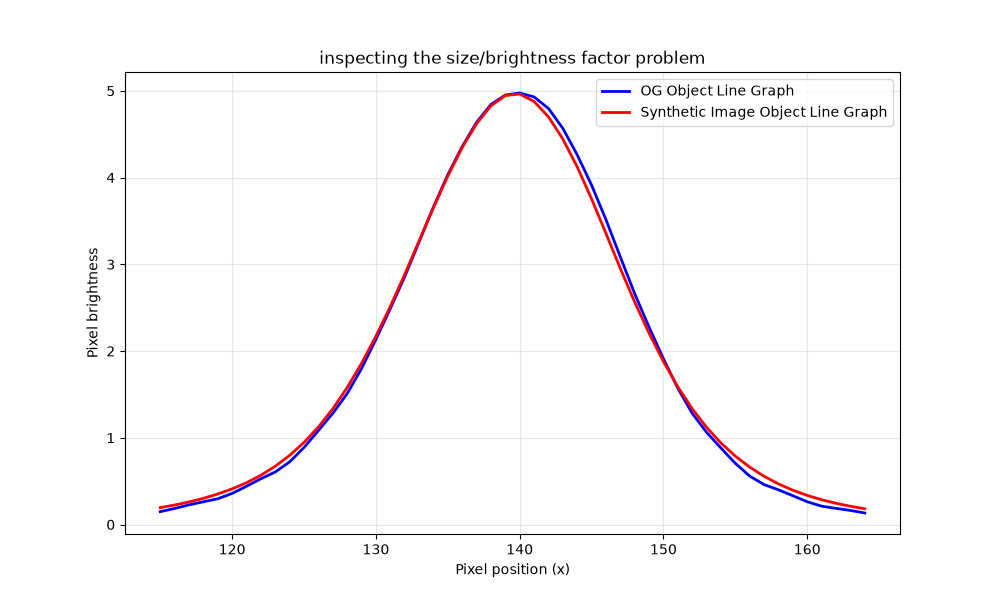

(63, 63)


In [15]:
synthetic_image = create_synthetic_image(r_band.shape, psf_data_enlarged, xs_without_target, ys_without_target, fluxes_without_target)
#identify the lowest y-value in the array to find the bottom object (what we will use as reference to find the mismatch)
bottom_object_coord = np.argmin(ys) #get the lowest value in the array

btm_obj_x = int(round(xs[bottom_object_coord])) #round coords to nearest 
btm_obj_y = int(round(ys[bottom_object_coord]))

#slicing the object in the center
slice_center_row = btm_obj_y
slice_start_col = btm_obj_x - 25 #creating a 50x50 around the object (the area that we will graph)
slice_end_col = btm_obj_x + 25

og_line_graph = r_band[slice_center_row, slice_start_col:slice_end_col] #the logic is r_band[50,100] outputs the brightness (the flux value) at row 50, column 100
synthetic_line_graph = synthetic_image[slice_center_row, slice_start_col:slice_end_col]
line_graph_px_positions = np.arange(slice_start_col, slice_end_col)

plt.figure(figsize=(10, 6))
plt.plot(line_graph_px_positions, og_line_graph, label='OG Object Line Graph', color='blue', linewidth=2)
plt.plot(line_graph_px_positions, synthetic_line_graph, label='Synthetic Image Object Line Graph', color='red', linewidth=2)
plt.xlabel('Pixel position (x)')
plt.ylabel('Pixel brightness')
plt.title('inspecting the size/brightness factor problem')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(psf_data.shape)

### Aperture Photometry Verification
Before subtracting the synthetic image, we will measure the fluxes of the original image to ensure that it corresponds to the online data (https://www.legacysurvey.org/viewer/ls-dr10/cat?ralo=192.6000&rahi=192.6020&declo=-28.2679&dechi=-28.2659&objid=3645)<br>
<br>
After importing `SkyCoord`, `SkyCircularAperture`, and `aperture_photometry`, we start by creating a SkyCoord object for the target's position.<br>
Next, we create a list of the multiple radii, and convert them from normal Python floats to **arcseconds** using `u.arcsec` from Astropy Units.<br>
After that, we create the list of apertures using the `SkyCircularAperture` function from Photutils and every radii from our list.<br>
To actually measure the flux, we use `aperture_photometry`. We pass it the main image, the apertures, and the wcs so that it automatically aligns the sky coordinates with the image pixels.<br>
Lastly, to plot everything, we have to conver the `SkyCircularAperture` into a `PixelAperture`.


 ------ APERTURE PHOTOMETRY FLUXES RESULTS ------
 id      x_center           y_center         sky_center      aperture_sum_0     aperture_sum_1    aperture_sum_2    aperture_sum_3    aperture_sum_4   aperture_sum_5    aperture_sum_6 
                                              deg,deg                                                                                                                                   
--- ------------------ ------------------ ---------------- ------------------ ----------------- ----------------- ----------------- ----------------- ---------------- -----------------
  1 122.21549346428947 163.49999781742451 192.601,-28.2669 318.44987331685195 532.7294235667815 679.4873376666083 864.4526178784251 907.3734902266098 927.229371266862 1260.410456477822
None
----------------------------------------------------

--- FLUX LIST ---
Radius: 0.5        arcsec -> Flux: 318.4499
Radius: 0.75       arcsec -> Flux: 532.7294
Radius: 1.0        arcsec -> Flux: 679.4873


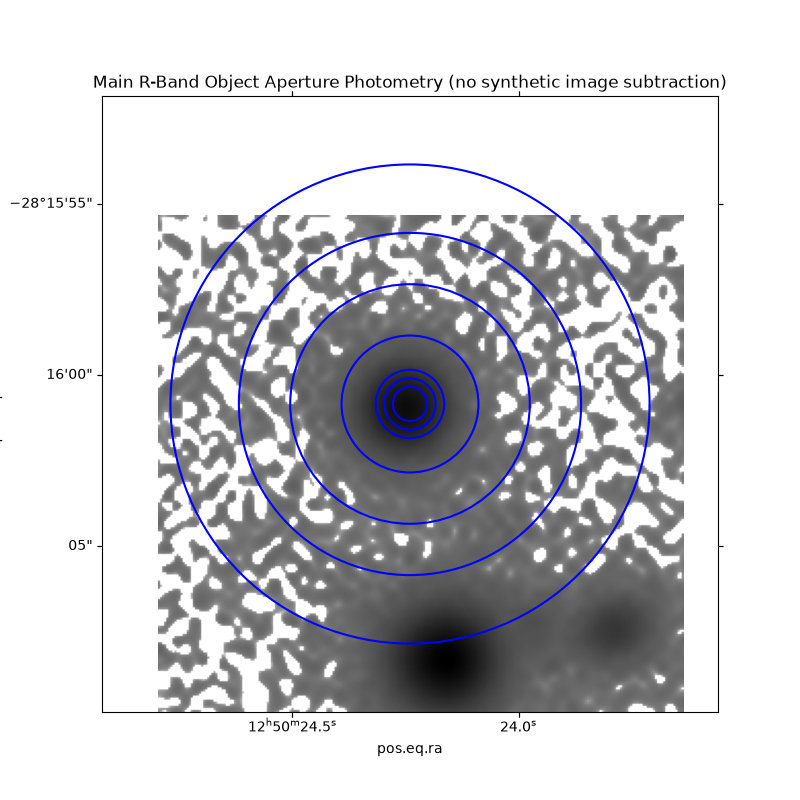

In [19]:
with fits.open(main_image_cutout) as hdu_list: #use with to safely close the file
    r_band_2d = hdu_list[0].data[1, :, :]
    wcs_2 = WCS(hdu_list[0].header, naxis=2)

main_object_position = SkyCoord(ra=main_object_ra, dec=main_object_dec, unit='deg')

apflux_radii = [0.5, 0.75, 1.0, 2.0, 3.5, 5.0, 7.0] * u.arcsec

original_apertures = [SkyCircularAperture(main_object_position, r) for r in apflux_radii]
#for apflux in original_apertures:
 #   print(apflux)

photometry_table = aperture_photometry(r_band_2d, original_apertures, wcs=wcs_2) #this is whats doing the actual measuring of fluxes
print("\n ------ APERTURE PHOTOMETRY FLUXES RESULTS ------")
print(photometry_table.pprint_all())
print("----------------------------------------------------\n")

print("--- FLUX LIST ---")
for i, radius in enumerate(apflux_radii): #outputting the results in a much cleaner way #enumerate allow to loop throguh a list and have access to both the index and the element
    flux_val = photometry_table[f'aperture_sum_{i}'][0]
    print(f"Radius: {radius:<10} -> Flux: {flux_val:.4f}") #rounded to .4 decimal places
print("-----------------------\n")


fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(1, 1, 1, projection=wcs_2) #setting the plot with the correct celestial alignment
ax.imshow(r_band_2d, cmap = 'Greys', norm = LogNorm(), origin = 'lower') #showing the main image

#convert the sky circles to pixel circles and draw them
for sky_aperture in original_apertures:
    pixel_aperture = sky_aperture.to_pixel(wcs_2)
    pixel_aperture.plot(ax=ax, color='blue', lw=1.5)

pixel_position = main_object_position.to_pixel(wcs_2)
ax.set_xlim(pixel_position[0] - 150, pixel_position[0] + 150) #zooming in slightly
ax.set_ylim(pixel_position[1] - 150, pixel_position[1] + 150)
plt.title("Main R-Band Object Aperture Photometry (no synthetic image subtraction)")
plt.show()




### Synthetic Image Subtraction
We will now subtract the newly created PSF Synthetic Image from the original, r-band Image. <br>
The process is extremely easy, we define a new variable which is the result of `r_band` (the original image) - `synthetic_image` (the PSF stamp with all the neighboring, unrelated sources). This should result in a clean, interfrences-free image of our target.

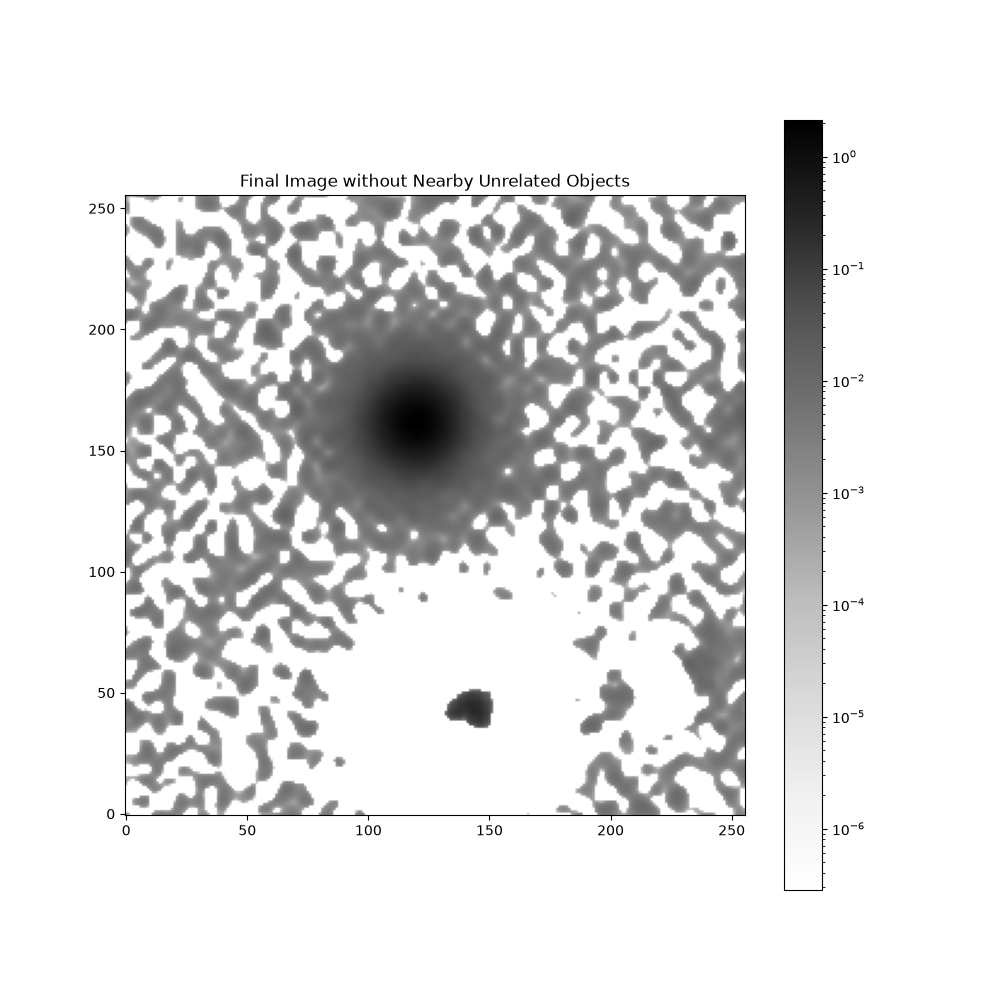

In [17]:
final_image = r_band - synthetic_image

#norm = ImageNormalize(r_band, interval=ZScaleInterval())
plt.figure(figsize=(10,10))
plt.imshow(final_image, cmap="Grays", origin="lower", norm=LogNorm())
plt.colorbar()
plt.title("Final Image without Nearby Unrelated Objects")
plt.show()

### Final Aperture Photometry
Lastly, we perform Aperture Photometry on the new, interferences-free image. The process is the exact same as previously, except that we use the `final_image` instead of the original `r_band` image to perform aperture photometry and plot.


 ------ APERTURE PHOTOMETRY FLUXES RESULTS ------
 id      x_center           y_center         sky_center      aperture_sum_0    aperture_sum_1    aperture_sum_2    aperture_sum_3    aperture_sum_4    aperture_sum_5    aperture_sum_6 
                                              deg,deg                                                                                                                                   
--- ------------------ ------------------ ---------------- ----------------- ----------------- ----------------- ----------------- ----------------- ----------------- -----------------
  1 122.21549346428947 163.49999781742451 192.601,-28.2669 318.4411998078365 532.6975909195722 679.4042850188982 863.6401183532371 900.7895835738044 897.8975811457349 827.4433490781435
None
----------------------------------------------------

--- FLUX LIST ---
Radius: 0.5        arcsec -> Flux: 318.4412
Radius: 0.75       arcsec -> Flux: 532.6976
Radius: 1.0        arcsec -> Flux: 679.4043


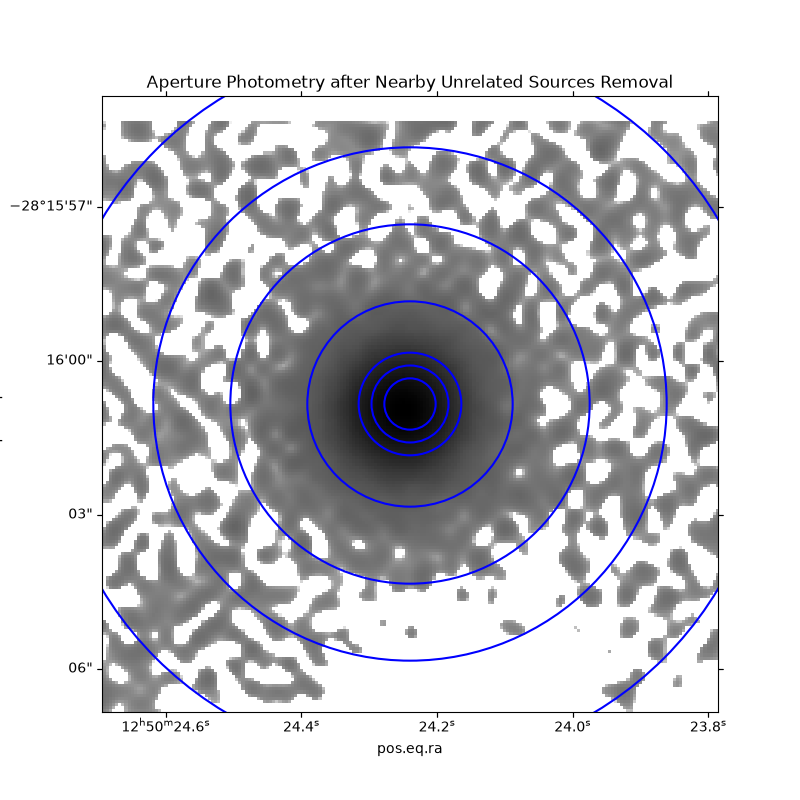

In [18]:
photometry_table = aperture_photometry(final_image, original_apertures, wcs=wcs_2) #this is whats doing the actual measuring of fluxes
print("\n ------ APERTURE PHOTOMETRY FLUXES RESULTS ------")
print(photometry_table.pprint_all())
print("----------------------------------------------------\n")

print("--- FLUX LIST ---")
for i, radius in enumerate(apflux_radii): #outputting the results in a much cleaner way #enumerate allow to loop throguh a list and have access to both the index and the element
    flux_val = photometry_table[f'aperture_sum_{i}'][0]
    print(f"Radius: {radius:<10} -> Flux: {flux_val:.4f}") #rounded to .4 decimal places
print("-----------------------\n")


fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(1, 1, 1, projection=wcs_2) #setting the plot with the correct celestial alignment
ax.imshow(final_image, cmap = 'Greys', norm = LogNorm(), origin = 'lower') #showing the main image

#convert the sky circles to pixel circles and draw them
for sky_aperture in original_apertures:
    pixel_aperture = sky_aperture.to_pixel(wcs_2)
    pixel_aperture.plot(ax=ax, color='blue', lw=1.5)

pixel_position = main_object_position.to_pixel(wcs_2)
ax.set_xlim(pixel_position[0] - 100, pixel_position[0] + 100) #zooming in slightly
ax.set_ylim(pixel_position[1] - 100, pixel_position[1] + 100)
plt.title("Aperture Photometry after Nearby Unrelated Sources Removal")
plt.show()